## Student Performance Indicator

#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('data/stud.csv')

In [5]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of the dataset

In [6]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform
### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [8]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

#### There are no missing values in the data set

### 3.2 Check Duplicates


In [10]:
df.duplicated().sum()

0

#### There are no duplicates  values in the data set


### 3.3 Check data types


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### 3.4 Checking the number of unique values of each column


In [14]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5 Check statistics of data set


In [15]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
math_score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading_score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing_score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading is higher = 17

### 3.7 Exploring Data


In [19]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [22]:
df['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

In [24]:
df['lunch'].str.split('/').str[0]

0      standard
1      standard
2      standard
3          free
4      standard
         ...   
995    standard
996        free
997        free
998    standard
999        free
Name: lunch, Length: 1000, dtype: object

In [25]:
df['lunch'] = df['lunch'].str.split('/').str[0]

In [26]:
df['lunch'].unique()

array(['standard', 'free'], dtype=object)

## here we removed the reduced value because it is same as free

In [28]:
print(f"Categories in 'gender' variable:{df['gender'].unique()}")

print(f"Categories in 'race_ethnicity' variable:{df['race_ethnicity'].unique()}")

print(f"Categories in 'parental_level_of_education' variable:{df['parental_level_of_education'].unique()}")

print(f"Categories in 'lunch' variable:{df['lunch'].unique()}")

print(f"Categories in 'test_preparation_course' variable:{df['test_preparation_course'].unique()}")



Categories in 'gender' variable:['female' 'male']
Categories in 'race_ethnicity' variable:['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental_level_of_education' variable:["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:['standard' 'free']
Categories in 'test_preparation_course' variable:['none' 'completed']


In [30]:
num_feature = [feature for feature in df.columns if df[feature].dtype != "O"]
cate_feature = [feature for feature in df.columns if df[feature].dtype == "O"]

print(f"we have {len(num_feature)} numerical featuer : {num_feature}")
print(f"we have {len(cate_feature)} numerical featuer : {cate_feature}")

we have 3 numerical featuer : ['math_score', 'reading_score', 'writing_score']
we have 5 numerical featuer : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### 3.8 Adding columns for "Total Score" and "Average"


In [33]:
df['Total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['Average_score'] = df['Total_score']/3
df.head(1)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667


In [43]:
df[df['reading_score'] == 100]['reading_score'].count()

17

In [44]:
reading_full = df[df['reading_score'] == 100]['reading_score'].count()
writing_full = df[df['writing_score'] == 100]['writing_score'].count()
math_full = df[df['math_score'] == 100]['math_score'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [45]:
reading_less_20 = df[df['reading_score'] <= 20]['reading_score'].count()
writing_less_20 = df[df['writing_score'] <= 20]['writing_score'].count()
math_less_20 = df[df['math_score'] <= 20]['math_score'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


#####  Insights
 - From above values we get students have performed the worst in Maths 
 - Best performance is in reading section

### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

#### 4.1.1 Histogram & KDE


<Axes: xlabel='Average_score', ylabel='Count'>

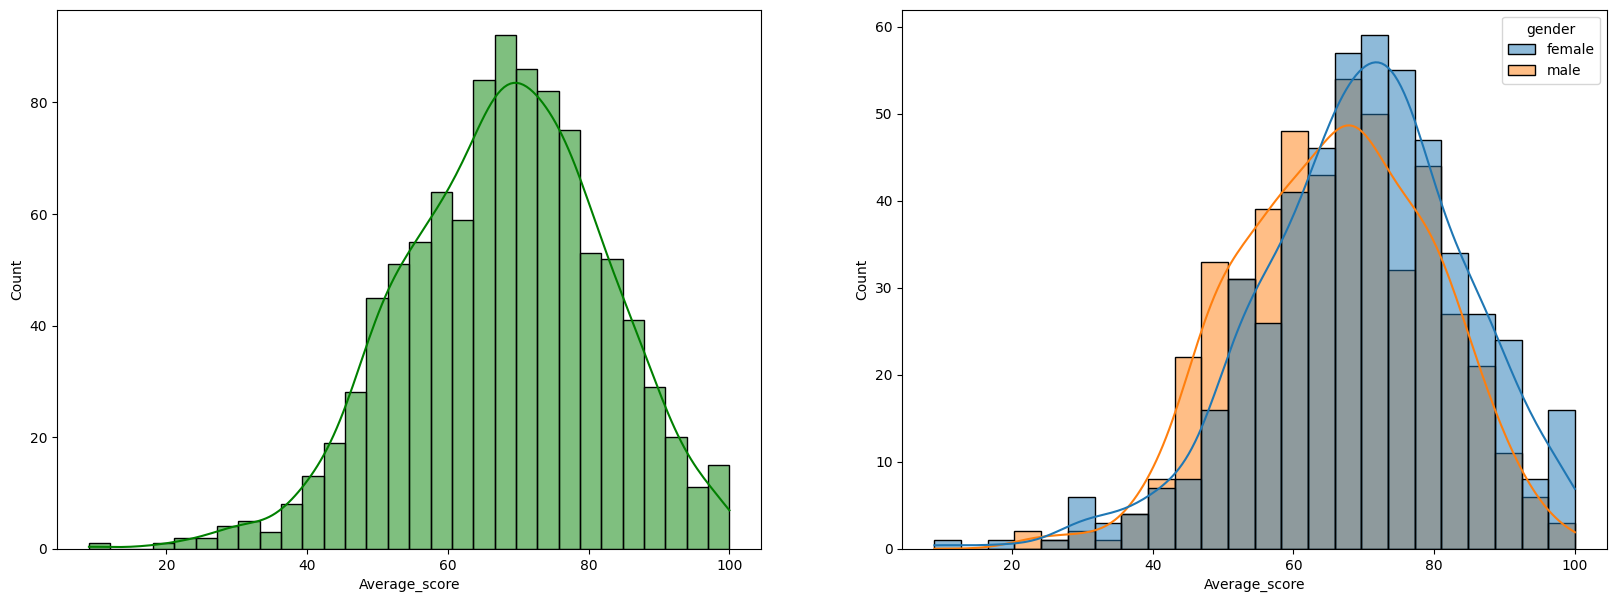

In [70]:
plt.figure(figsize=(20, 7))
plt.subplot(1,2,1)
sns.histplot(data=df,x=df['Average_score'],bins=30,kde=True,color='g')
plt.subplot(1,2,2)
sns.histplot(data=df,x=df['Average_score'],kde=True,hue='gender')

<Axes: xlabel='Total_score', ylabel='Count'>

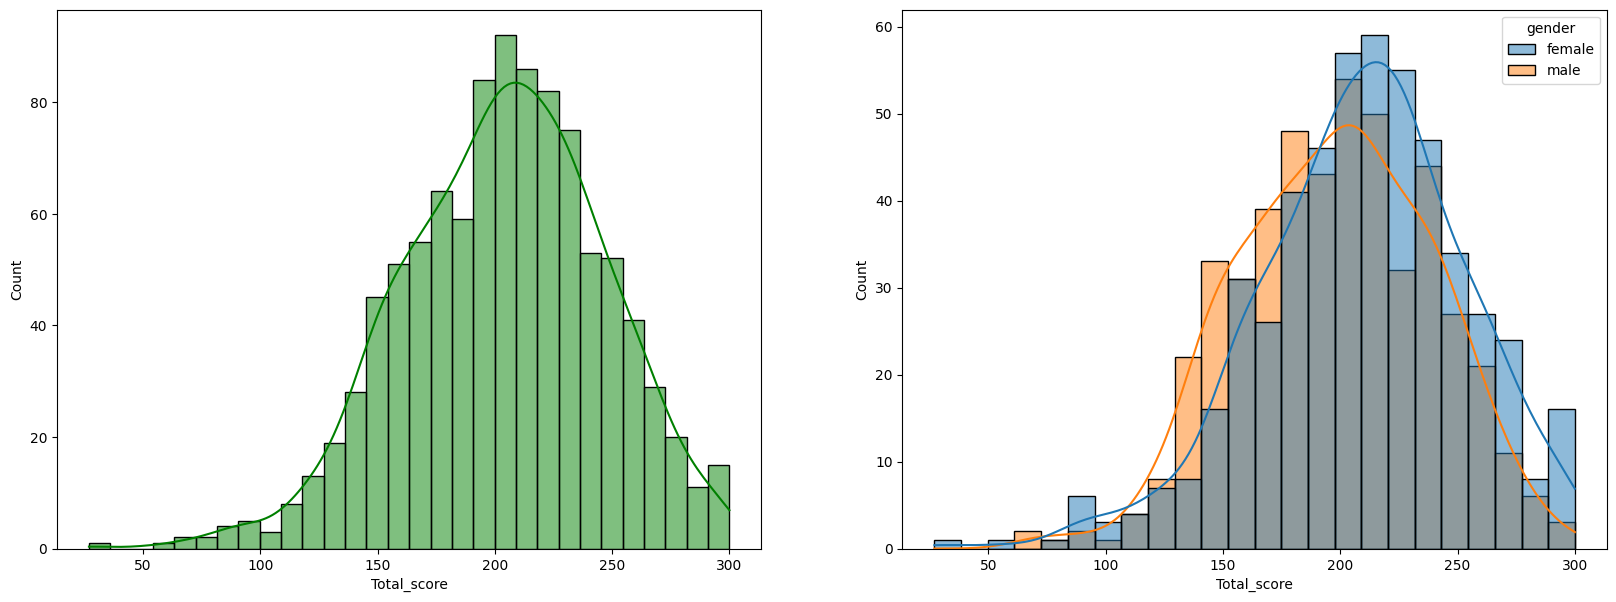

In [69]:
plt.figure(figsize=(20, 7))
plt.subplot(1,2,1)
sns.histplot(data=df,x=df['Total_score'],bins=30,kde=True,color='g')
plt.subplot(1,2,2)
sns.histplot(data=df,x=df['Total_score'],kde=True,hue='gender')

#####  Insights
- Female students tend to perform well then male students.

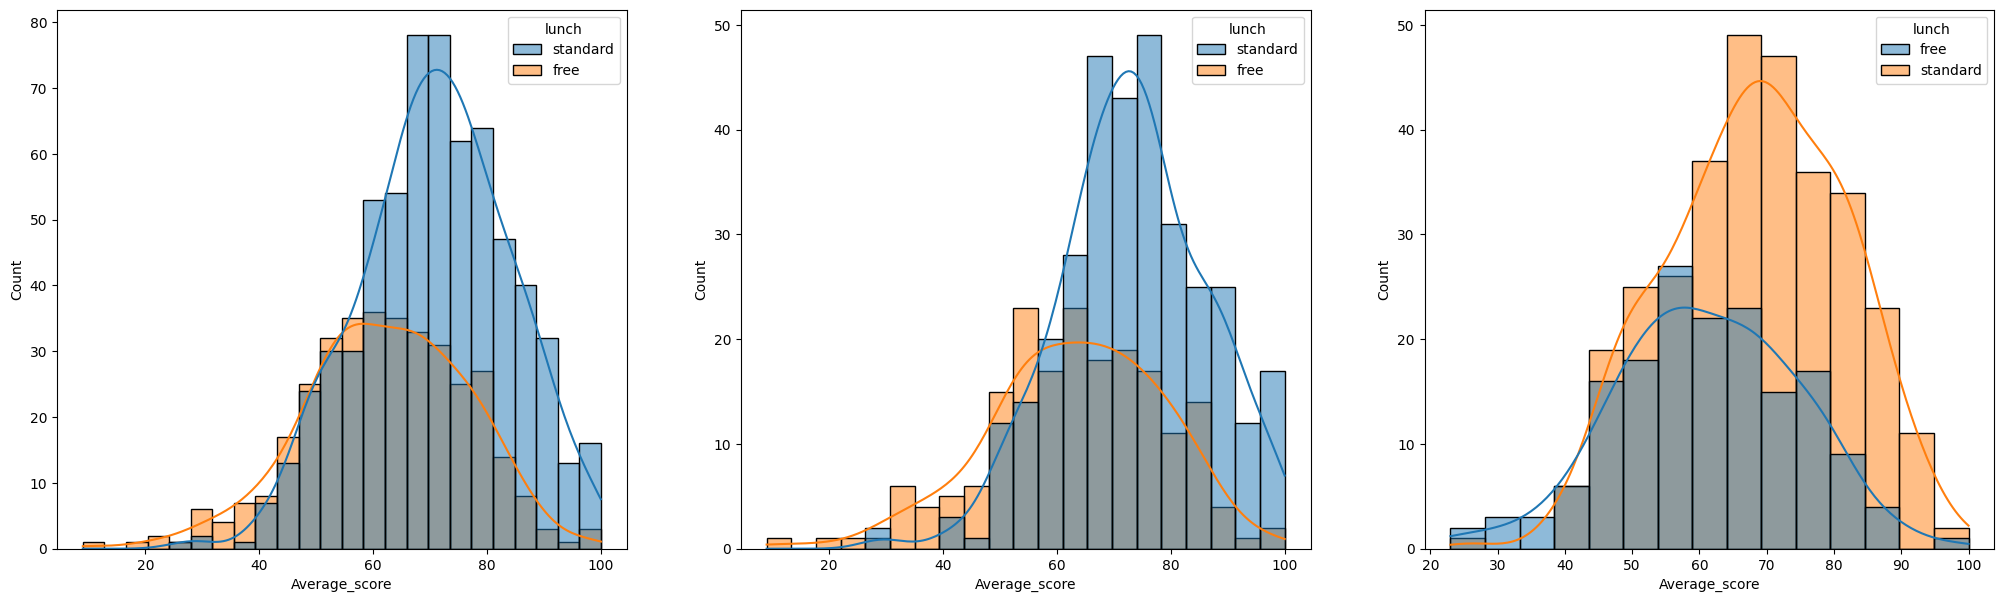

In [71]:
plt.figure(figsize=(25, 7))
plt.subplot(1,3,1)
sns.histplot(data=df,x=df['Average_score'],kde=True,hue=df['lunch'])
plt.subplot(1,3,2)
sns.histplot(data=df[df.gender=='female'],x=df['Average_score'],kde=True,hue='lunch')
plt.subplot(1,3,3)
sns.histplot(data=df[df.gender=='male'],x=df['Average_score'],kde=True,hue='lunch')
plt.show()

#####  Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams for both male or a female.

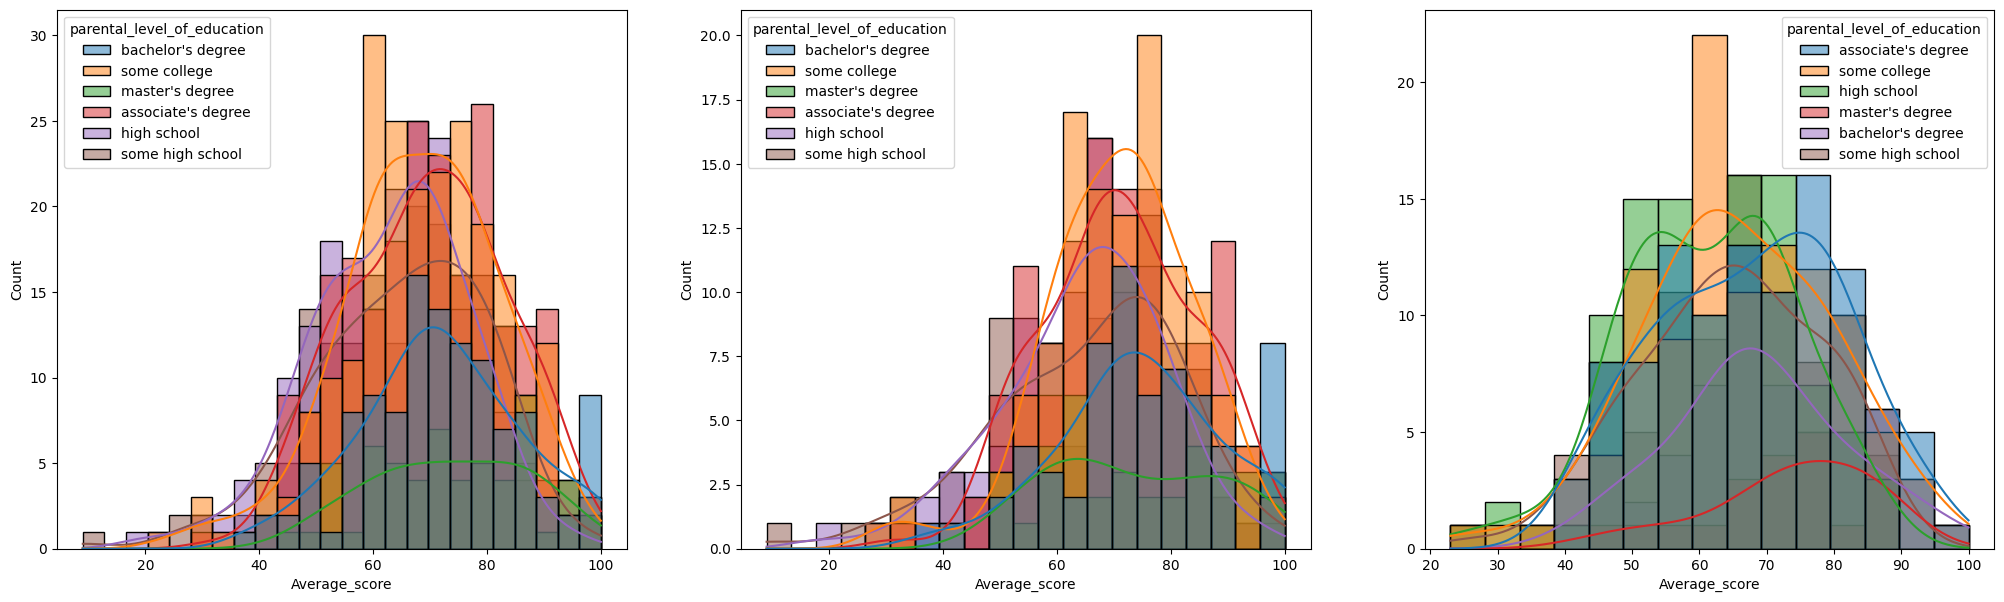

In [72]:
plt.figure(figsize=(25, 7))
plt.subplot(1,3,1)
sns.histplot(data=df,x=df['Average_score'],kde=True,hue=df['parental_level_of_education'])
plt.subplot(1,3,2)
sns.histplot(data=df[df.gender=='female'],x=df['Average_score'],kde=True,hue='parental_level_of_education')
plt.subplot(1,3,3)
sns.histplot(data=df[df.gender=='male'],x=df['Average_score'],kde=True,hue='parental_level_of_education')
plt.show()

#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or some collage degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

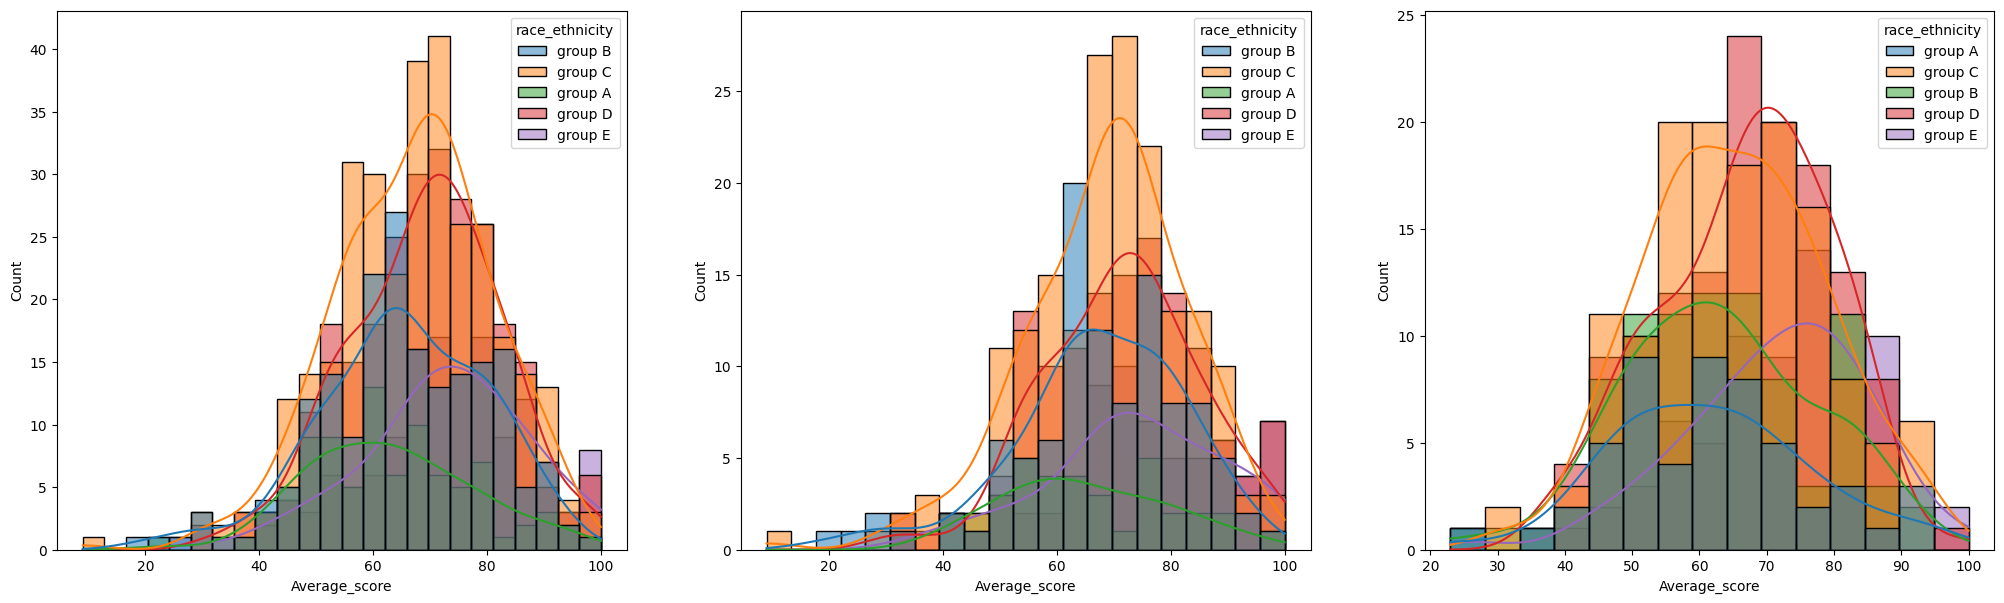

In [75]:
plt.figure(figsize=(25, 7))
plt.subplot(1,3,1)
sns.histplot(data=df,x=df['Average_score'],kde=True,hue=df['race_ethnicity'])
plt.subplot(1,3,2)
sns.histplot(data=df[df.gender=='female'],x=df['Average_score'],kde=True,hue='race_ethnicity')
plt.subplot(1,3,3)
sns.histplot(data=df[df.gender=='male'],x=df['Average_score'],kde=True,hue='race_ethnicity')
plt.show()

#####  Insights
- Students of group A and group E tends to perform poorly in exam.
- Students of group A and group E tends to perform poorly in exam irrespective of whether they are male or female

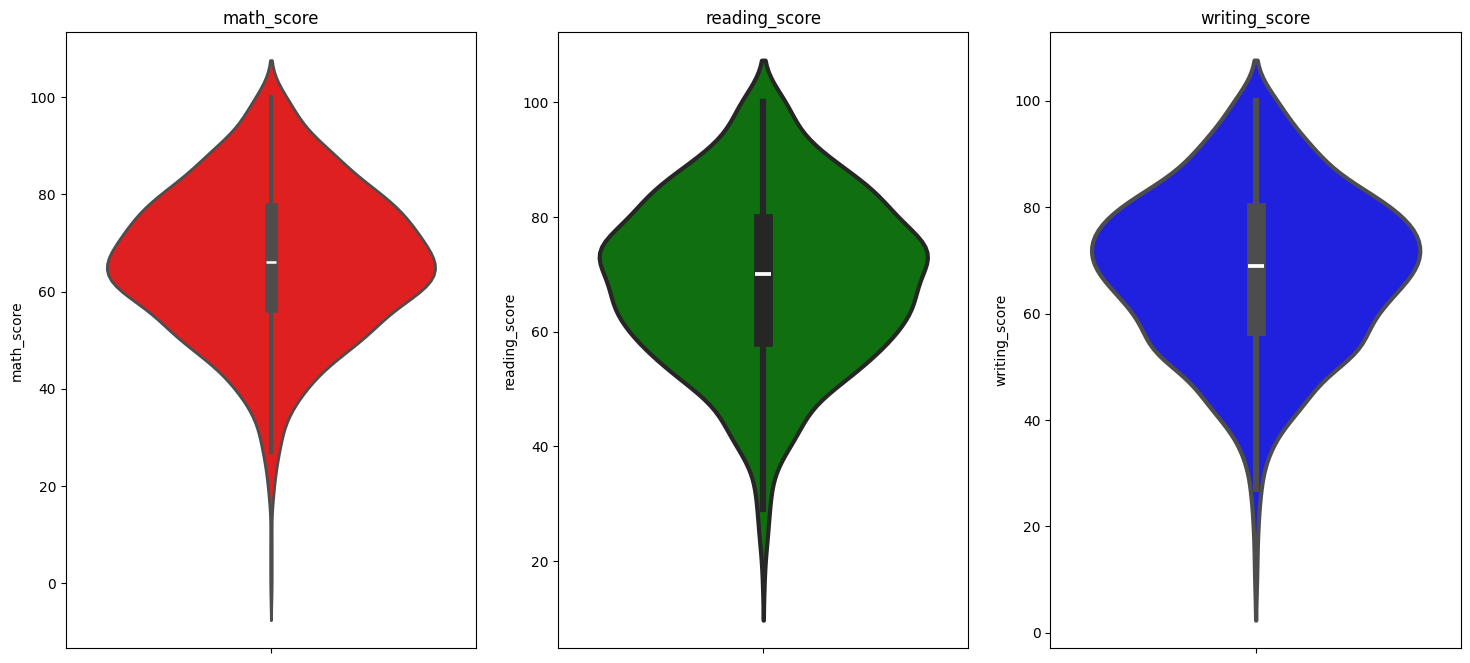

In [90]:
plt.figure(figsize=(18,8))
plt.subplot(1, 3, 1)
plt.title('math_score')
sns.violinplot(y='math_score',data=df,color='red',linewidth=2)
plt.subplot(1, 3, 2)
plt.title('reading_score')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 3, 3)
plt.title('writing_score')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

#### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

#### 4.3 Multivariate analysis using pieplot


In [91]:
df['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

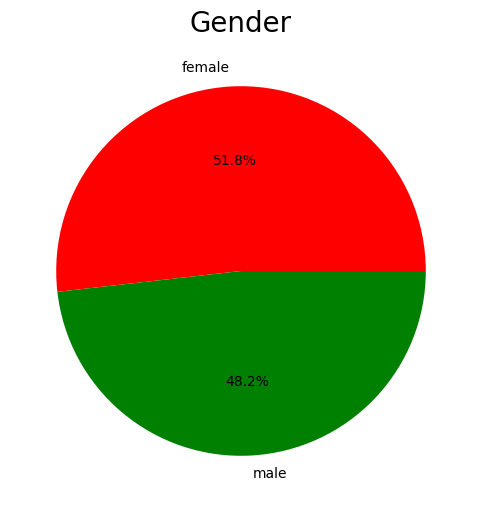

In [112]:
color = ['r','g']
plt.figure(figsize=(12,6))
plt.pie(x=df['gender'].value_counts().values,labels=df['gender'].value_counts().index,colors=color,autopct = '%1.1f%%')
plt.title('Gender', fontsize = 20)
plt.show()

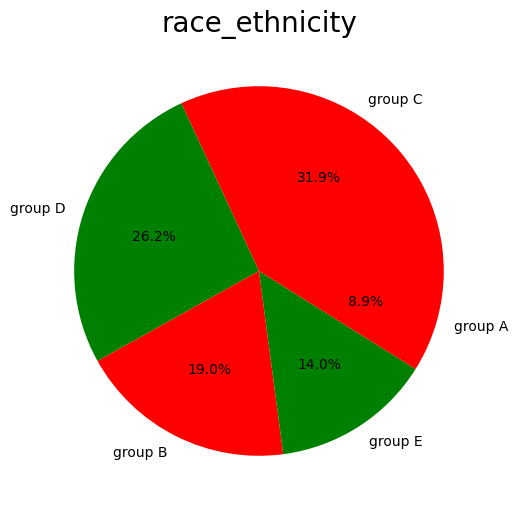

In [114]:
color = ['r','g']
plt.figure(figsize=(12,6))
plt.pie(x=df['race_ethnicity'].value_counts().values,labels=df['race_ethnicity'].value_counts().index,colors=color,autopct = '%1.1f%%')
plt.title('race_ethnicity', fontsize = 20)
plt.show()

In [109]:
df.head(1)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667


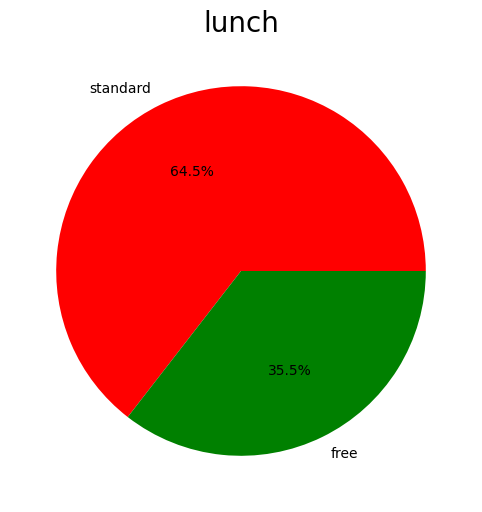

In [115]:
color = ['r','g']
plt.figure(figsize=(12,6))
plt.pie(x=df['lunch'].value_counts().values,labels=df['lunch'].value_counts().index,colors=color,autopct = '%1.1f%%')
plt.title('lunch', fontsize = 20)
plt.show()

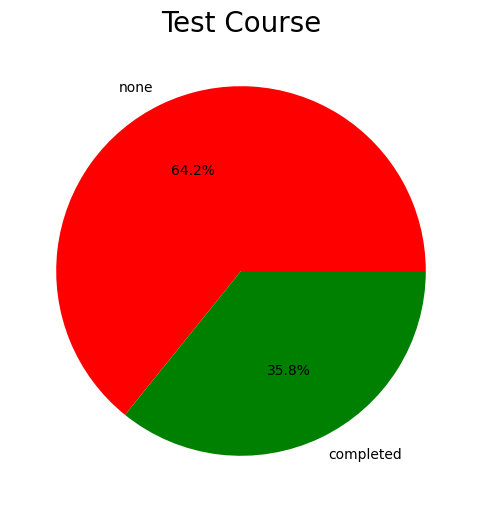

In [116]:
color = ['r','g']
plt.figure(figsize=(12,6))
plt.pie(x=df['test_preparation_course'].value_counts().values,labels=df['test_preparation_course'].value_counts().index,colors=color,autopct = '%1.1f%%')
plt.title('Test Course', fontsize = 20)
plt.show()

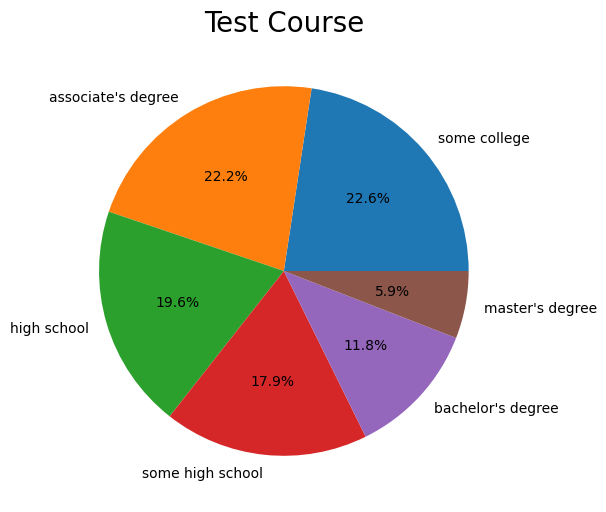

In [117]:
# color = ['r','g']
plt.figure(figsize=(12,6))
plt.pie(x=df['parental_level_of_education'].value_counts().values,labels=df['parental_level_of_education'].value_counts().index,autopct = '%1.1f%%')
plt.title('Test Course', fontsize = 20)
plt.show()

#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in none test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"


#### 4.4 Feature Wise Visualization
#### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?


#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

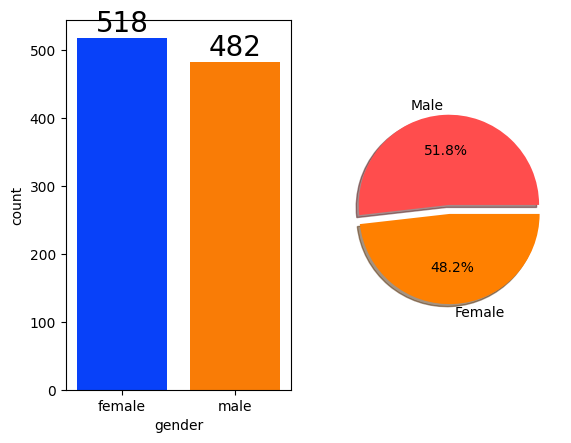

In [154]:
plt.Figure(figsize=(25,7))
plt.subplot(1,2,1)
a = sns.countplot(x=df['gender'],data=df,palette ='bright',saturation=0.95)
for contain in a.containers:
    a.bar_label(contain,color='black',size=20)

plt.subplot(1,2,2)  
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

In [127]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [128]:
gender_group = df.groupby('gender').count()
gender_group

,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
gender,,,,,,,,,
female,518,518,518,518,518,518,518,518,518
male,482,482,482,482,482,482,482,482,482


In [131]:
gender_group['Average_score'][0], gender_group['math_score'][0]

(518, 518)

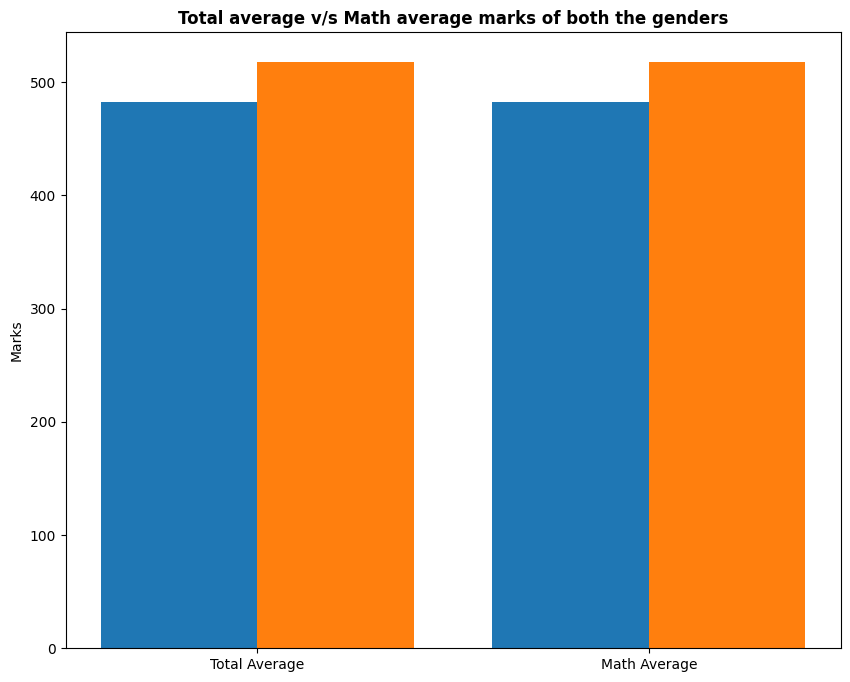

In [141]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['Average_score'][0], gender_group['math_score'][0]]
male_scores = [gender_group['Average_score'][1], gender_group['math_score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.2 RACE_EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?


#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

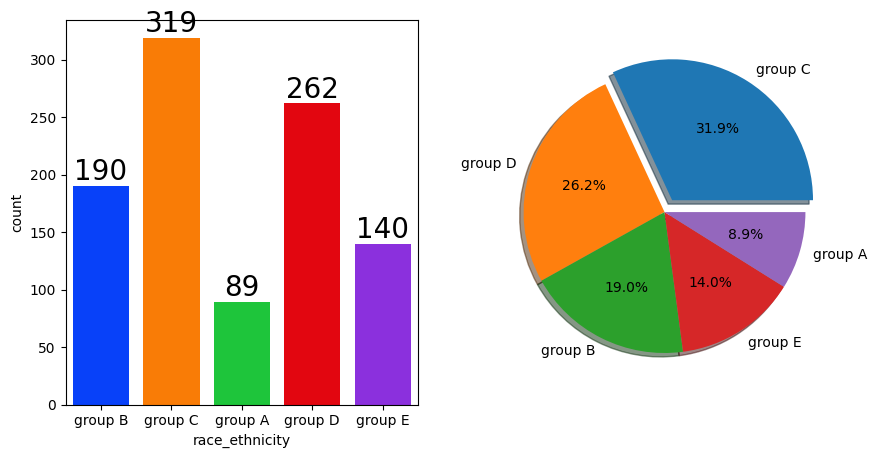

In [150]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
a = sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',saturation=0.95)
for contain in a.containers:
    a.bar_label(contain,color='black',size=20)

plt.subplot(1,2,2)    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()  

In [ ]:
# a=sns.countplot(x='quality',data=df,hue='type',palette='Set3',width=1)

# for i in a.containers:
#   a.bar_label(i)

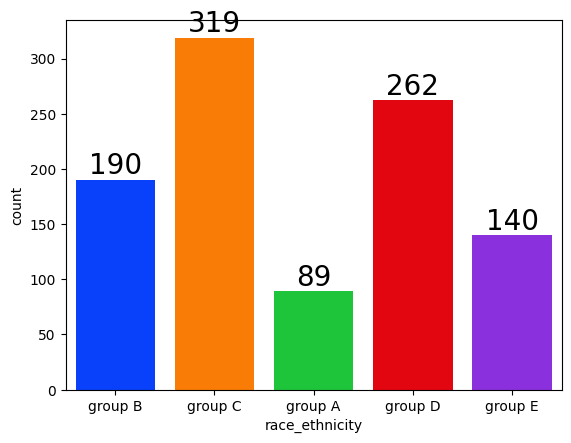

In [147]:
# a = sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',saturation=0.95)
# for contain in a.containers:
#     a.bar_label(contain,color='black',size=20)

#### Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )


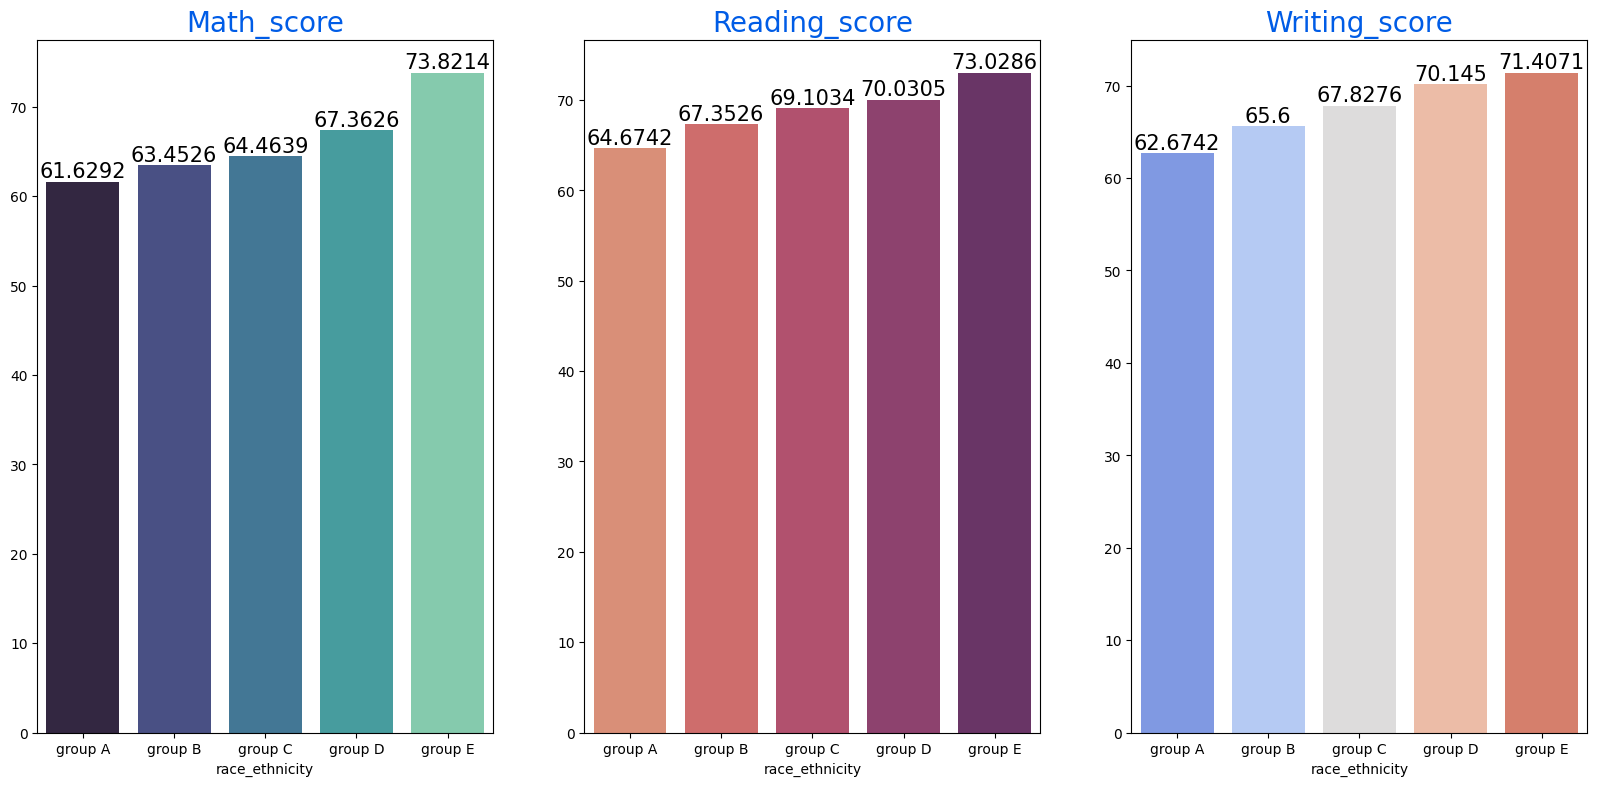

In [162]:
Group_data2=df.groupby('race_ethnicity')

plt.figure(figsize=(20,9))
plt.subplot(1,3,1)
a = sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako')
plt.title('Math_score',color='#005ce6',size=20)

for contain in a.containers:
    a.bar_label(contain,color='black',size=15)


plt.subplot(1,3,2)
b = sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare')
plt.title('Reading_score',color='#005ce6',size=20)

for contain in b.containers:
    b.bar_label(contain,color='black',size=15)

plt.subplot(1,3,3)
c = sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm')
plt.title('Writing_score',color='#005ce6',size=20)

for container in c.containers:
    c.bar_label(container,color='black',size=15)

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

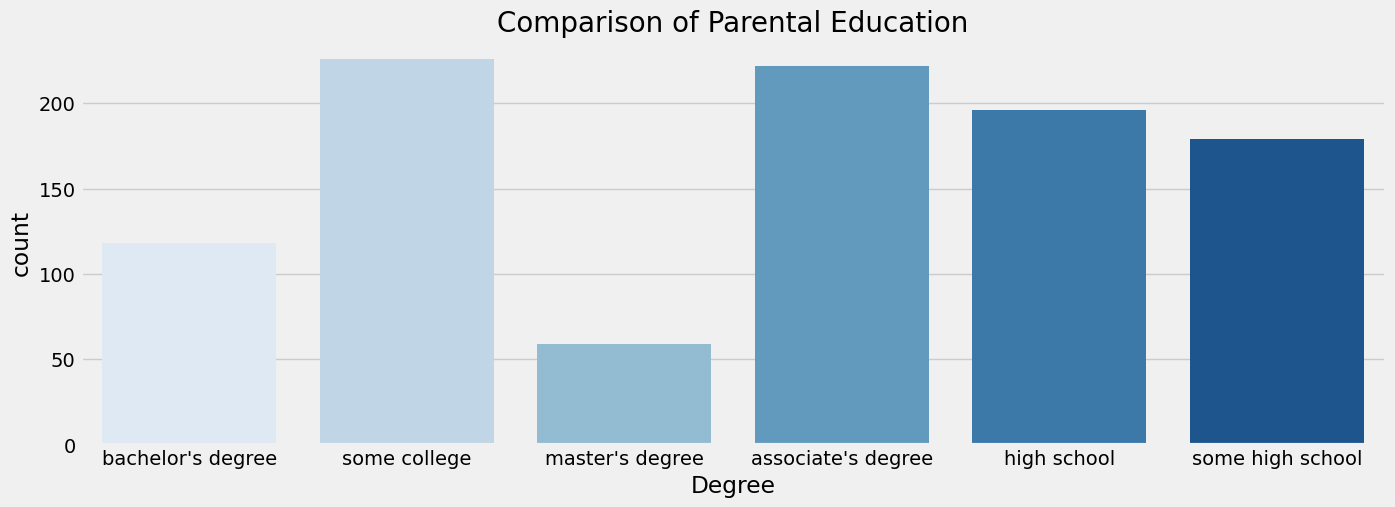

In [165]:
plt.figure(figsize=(15,5))
plt.style.use('fivethirtyeight')
sns.countplot(x=df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

#### Insights 
- Largest number of parents are from some college.

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

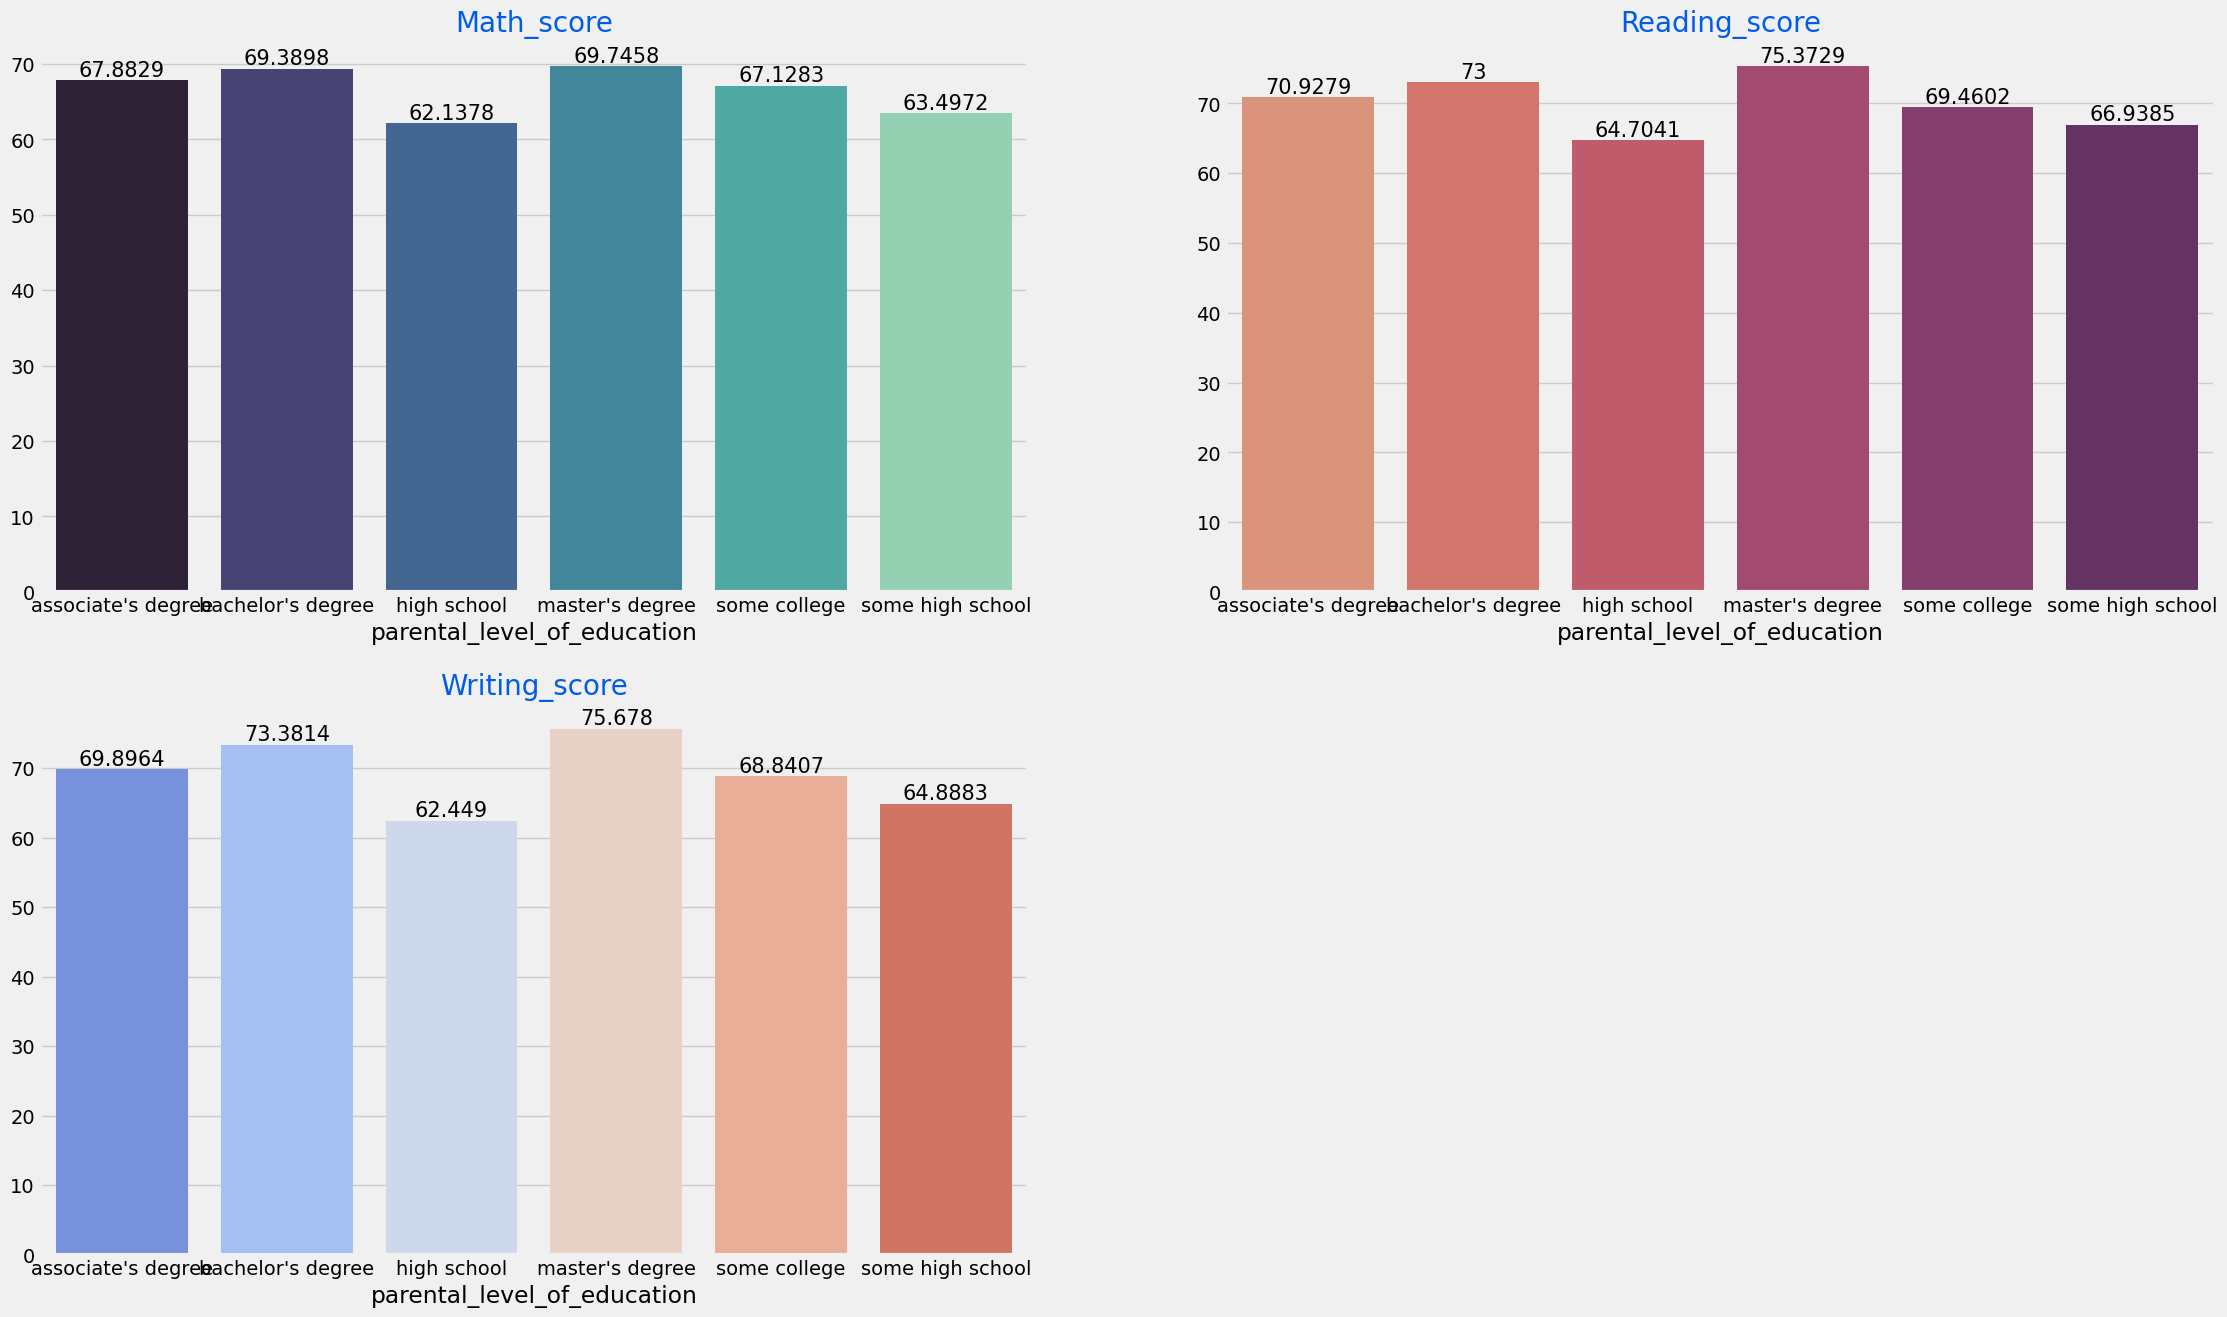

In [193]:
Group_data3=df.groupby('parental_level_of_education')

plt.figure(figsize=(25,15))
plt.subplot(2,2,1)
a = sns.barplot(x=Group_data3['math_score'].mean().index,y=Group_data3['math_score'].mean().values,palette = 'mako')
plt.title('Math_score',color='#005ce6',size=20)

for contain in a.containers:
    a.bar_label(contain,color='black',size=15)


plt.subplot(2,2,2)
b = sns.barplot(x=Group_data3['reading_score'].mean().index,y=Group_data3['reading_score'].mean().values,palette = 'flare')
plt.title('Reading_score',color='#005ce6',size=20)

for contain in b.containers:
    b.bar_label(contain,color='black',size=15)

plt.subplot(2,2,3)
c = sns.barplot(x=Group_data3['writing_score'].mean().index,y=Group_data3['writing_score'].mean().values,palette = 'coolwarm')
plt.title('Writing_score',color='#005ce6',size=20)

for container in c.containers:
    c.bar_label(container,color='black',size=15)

    

<Axes: ylabel='parental_level_of_education'>

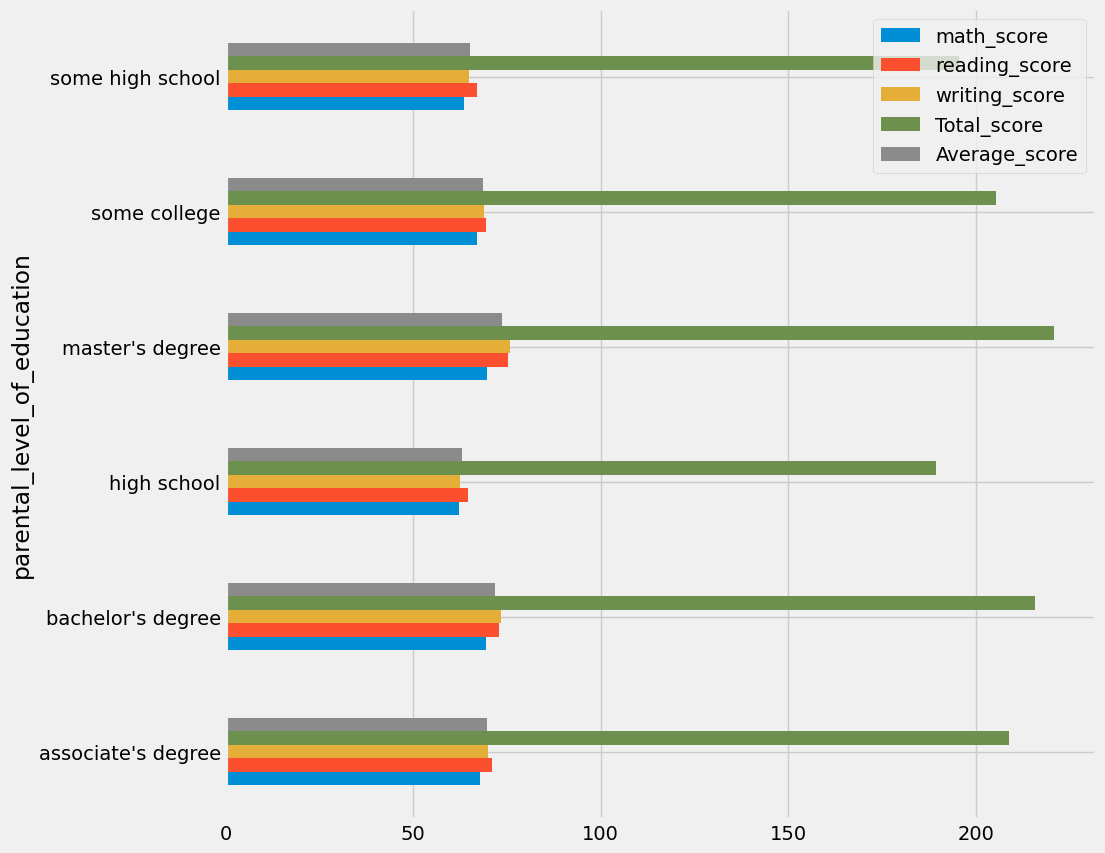

In [177]:
df.groupby('parental_level_of_education')[df.select_dtypes(include='number').columns].mean().plot(kind='barh', figsize=(10,10))

#### Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 4.4.4 LUNCH COLUMN 
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


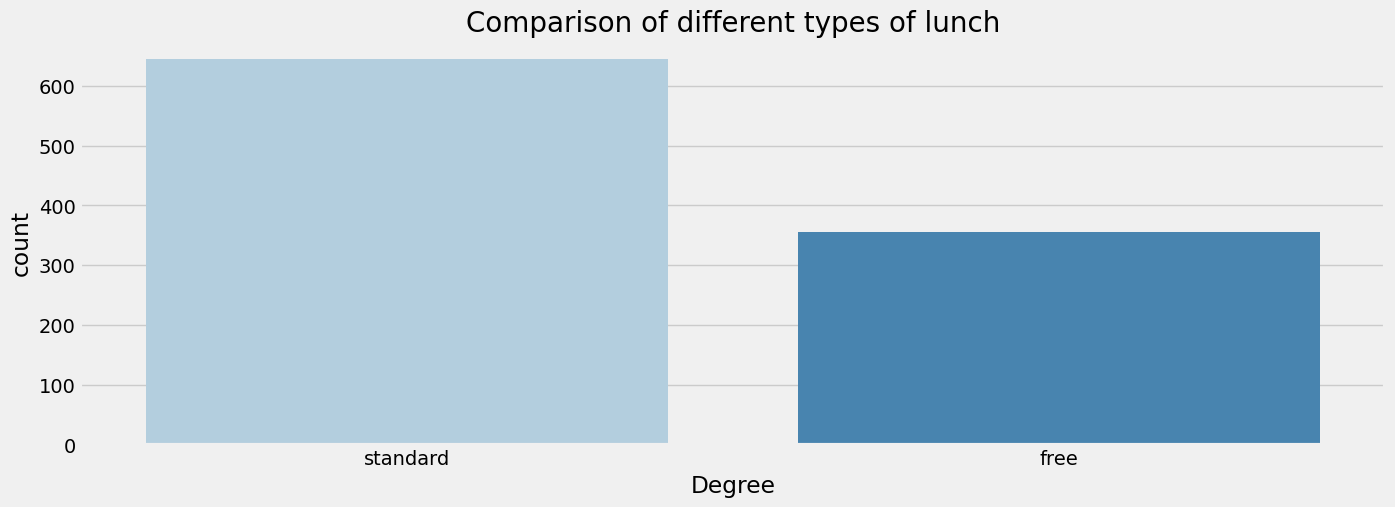

In [180]:
plt.figure(figsize=(15,5))
# plt.style.use('fivethirtyeight')
sns.countplot(x=df['lunch'], palette = 'Blues')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

#### Insights 
- Students being served Standard lunch was more than free lunch

#### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )


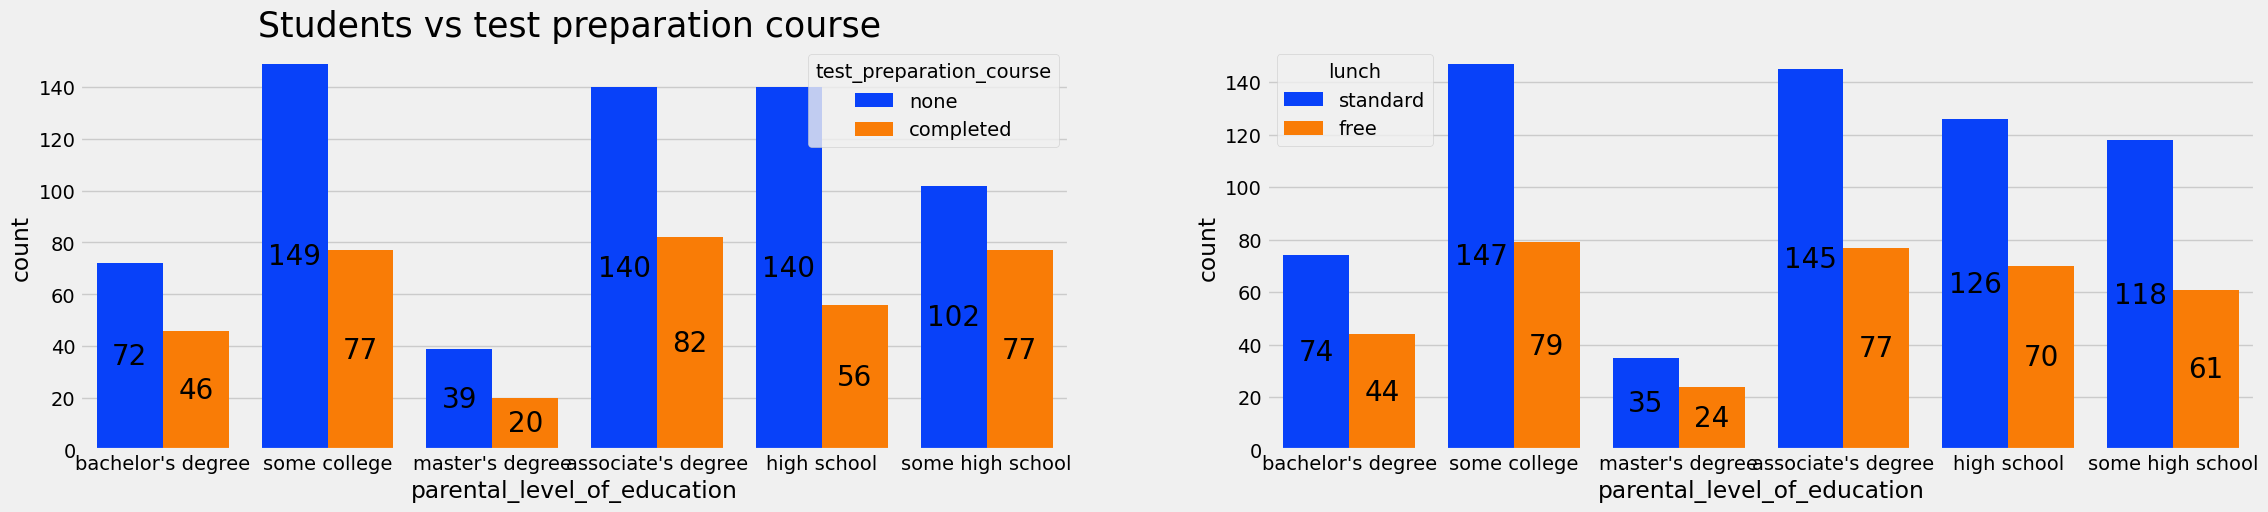

In [195]:
plt.figure(figsize=(25,5))
plt.subplot(1,2,1)

a = sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='test_preparation_course',saturation=0.95)
plt.title('Students vs test preparation course ',color='black',size=25)
for container in a.containers:
    a.bar_label(container,label_type='center',color='black',size=20)


plt.subplot(1,2,2)    
b = sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='lunch',saturation=0.95)
for container in b.containers:
    b.bar_label(container,label_type='center',color='black',size=20)  

#### Insights 
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

#### 4.4.5 TEST PREPARATION COURSE COLUMN 
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='writing_score'>

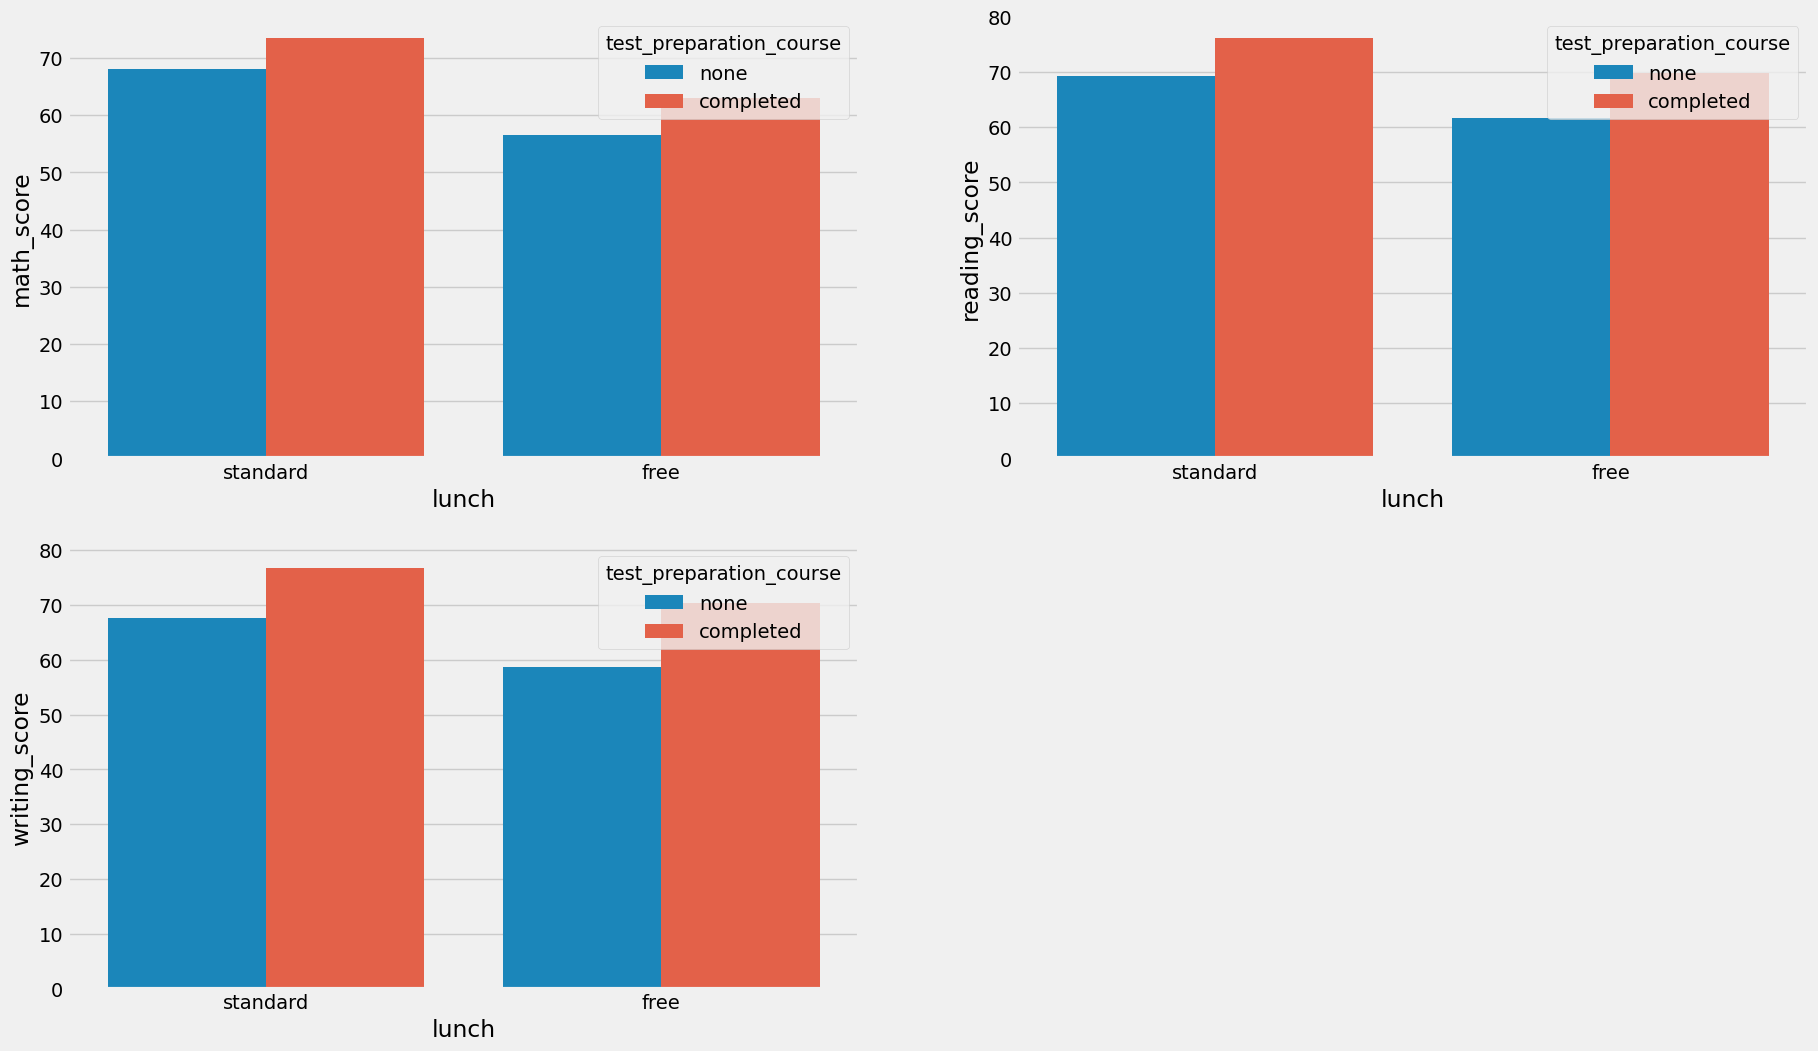

In [186]:
plt.figure(figsize=(20,12))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'],errorbar=None)
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'],errorbar=None)
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'],errorbar=None)

#### Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course


#### 4.4.6 CHECKING OUTLIERS

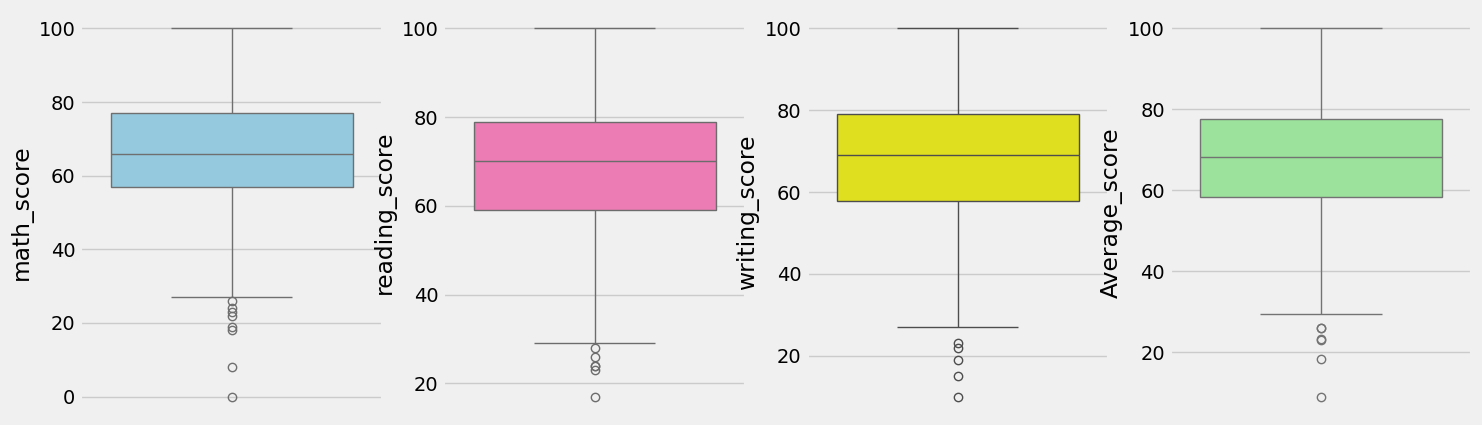

In [188]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['Average_score'],color='lightgreen')
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

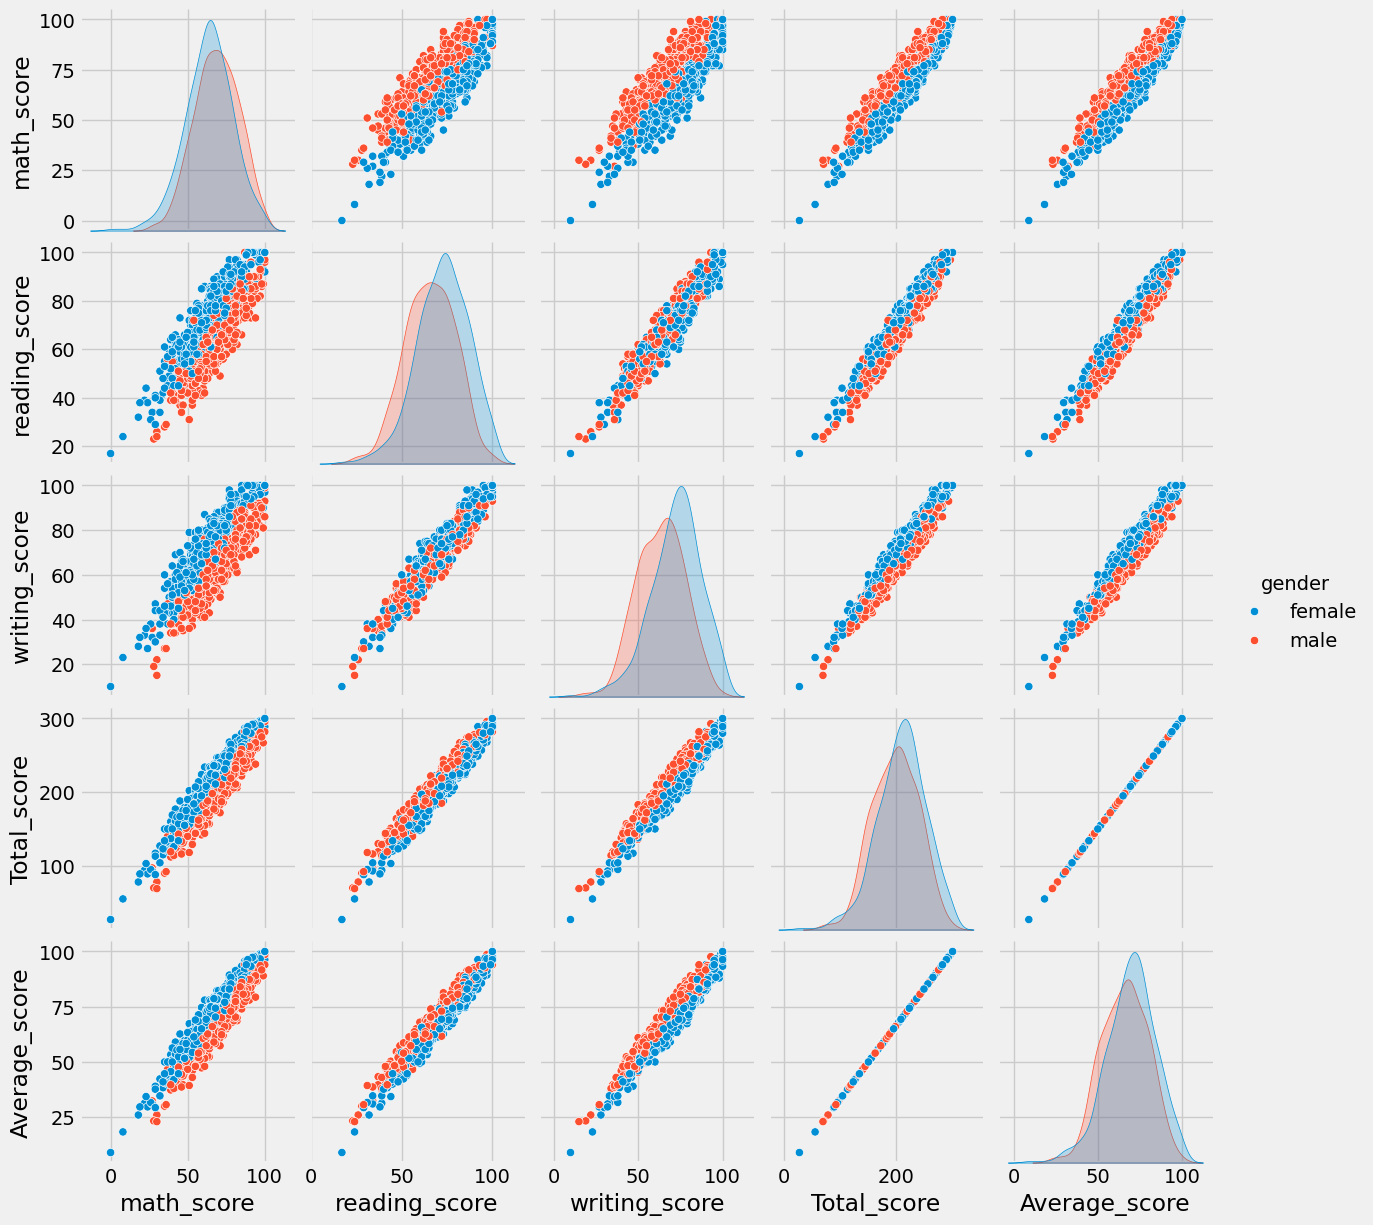

In [190]:
sns.pairplot(df,hue = 'gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.